## State Management

- A graph consists of nodes and edges between them
- Nodes are components of your workflow
- A workflow has a *state* which:
    - Makes your nodes aware of the current context by keeping track of the user input and previous computations. 
    - Allows you to persist your workflow execution at any point in time
    - Makes workflow interactive since a node can change the workflow's behavior by updating the state.

For simplicity, **state is a Python dictionary**. Nodes are Python functions that operate on this dictionary. 

In [ ]:
# Defining a state schema

from typing_extensions import TypedDict
# Note: A TypedDict is a Python type constructor that allows to define dictionaries 
# with a predefined set of keys and each key can have its own type

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str


# Define a simple workflow
from langgraph.graph import StateGraph, START, END

def analyze_job_description(state: JobApplicationState):
    print("...Analyzing a provided job description ...")
    return {"is_suitable": len(state["job_description"]) > 100}

def generate_application(state: JobApplicationState):
    print("...generating application...")
    return {"application": "some_fake_application"}

builder = StateGraph(JobApplicationState)

builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_edge("analyze_job_description", "generate_application")
builder.add_edge("generate_application", END)

graph = builder.compile()

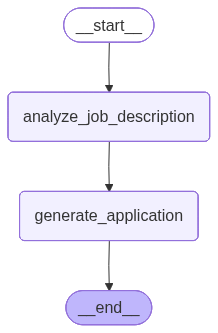

In [21]:
def display_graph(graph):
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
display_graph(graph)

When a node receives the state, it gets an immutable copy, not a reference to the actual state object. The node must return a dictionary containing the specific keys and values it wants to update. 

LangGraph handles merging these updates into the master state. The only way for a node to modify a state is to provide an output dictionary with key-value pairs
to be updated, and LangGraph will handle it.

In [22]:
res = graph.invoke({'job_description': 'fake_jd'})

...Analyzing a provided job description ...
...generating application...


In [23]:
print(res)

{'job_description': 'fake_jd', 'is_suitable': False, 'application': 'some_fake_application'}


We might use a conditional edge to route the flow of the graph based on data in the state. 

A **conditional edge** is a Python function that gets the current state as an input and returns a string with the node's name to be executed.

In [24]:
from typing import Literal
# Use the Literal to give the conditional edge type hint
# It's used by LangGraph to determine which destination nodes to connect to

builder = StateGraph(JobApplicationState)
builder.add_node('analyze_job_description', analyze_job_description)
builder.add_node('generate_application', generate_application)

def is_suitable_condition(state: JobApplicationState) -> Literal['generate_application', '__end__']:
    if state.get('is_suitable'):
        return 'generate_application'
    return END

builder.add_edge(START, 'analyze_job_description')
builder.add_conditional_edges(
    'analyze_job_description',
    is_suitable_condition
)
builder.add_edge('generate_application', END)

graph = builder.compile()

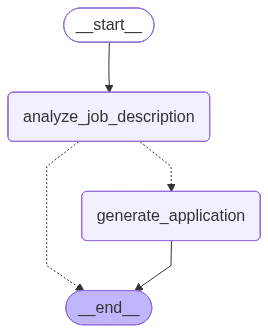

In [25]:
display_graph(graph)
# Conditional edges are visualized with dotted lines

## Reducers

So far, the nodes have changed the state by updating the value for a corresponding key. The default reducer on LangGraph *replaces the final value with the new value*. 

In [17]:
from typing import Annotated
from operator import add

class CustomState(TypedDict):
    all_items: Annotated[list[str], add]
    new_item: str


def step_1(state: CustomState):
    return {'all_items': ['item1'], 'new_item': 'item1'}

def step_2(state:CustomState):
    return {'all_items': ['item2'], 'new_item': 'item2'}

builder = StateGraph(CustomState)
builder.add_node('step_1', step_1)
builder.add_node('step_2', step_2)

builder.add_edge(START, 'step_1')
builder.add_edge('step_1', 'step_2')
builder.add_edge('step_2', END)

mygraph = builder.compile()

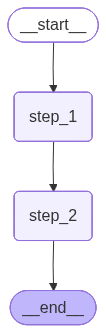

In [18]:
display_graph(mygraph)

In [11]:
res = graph.invoke({})
print(res)

{'all_items': ['item1', 'item2'], 'new_item': 'item2'}


### Tracking messages

In [12]:
from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages

class MyMessages(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# This is such a frequent pattern that there is a built-in state that we can inherit from
from langgraph.graph import MessagesState

# Typically, there is more state to track than just messages, so we see people subclass this state and add more fields, like
class State(MessagesState):
    documents: list[str]

## Making graphs configurable

**RunnableConfig is a typed dictionary** that gives you control over execution control settings. For example, you can control the maximum number of supersteps with the recursion_limit parameter. RunnableConfig also allows you to pass custom parameters as a separate dictionary under a configurable key.

In [33]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from operator import add
from typing import Annotated, Literal
from langchain_core.runnables import RunnableConfig


class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], add]

def analyze_job_description(state: JobApplicationState):
    print("...Analyzing a provided job description ...")
    return {
        "is_suitable": len(state["job_description"]) < 100,
        'actions': ['action1']
    }

def generate_application(state: JobApplicationState, config: RunnableConfig):
    model_provider = config["configurable"].get("model_provider", "Google")
    model_name = config["configurable"].get("model_name", "gemini-2.0-flash")
    print(f"...generating application with {model_provider} and {model_name} ...")
    return {"application": "some_fake_application", "actions": ["action2", "action3"]}

def is_suitable_condition(state: JobApplicationState) -> Literal['generate_application', '__end__']:
    if state.get('is_suitable'):
        return 'generate_application'
    return END

builder = StateGraph(JobApplicationState)
# NODES
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
# EDGES
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges(
    'analyze_job_description',
    is_suitable_condition
)
builder.add_edge('generate_application', END)

graph = builder.compile()

In [34]:
res = graph.invoke(
    {'job_description': 'fake_jd'}, # Pass initial state
    config={
        'configurable': {
            'model_provider': 'OpenAI',
            'model_name': 'gpt-4o'
        }
    }
)
print(res)

...Analyzing a provided job description ...
...generating application with OpenAI and gpt-4o ...
{'job_description': 'fake_jd', 'is_suitable': True, 'application': 'some_fake_application', 'actions': ['action1', 'action2', 'action3']}


## Structured Outputs

It is common to have stages of the workflow that require structured data rather than natural language responses. One way is to add instructions and to parse the output.

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

model = ChatOpenAI(model='gpt-5-nano')

job_description: str = "We are looking for a Data Scientist with experience in Python and LangChain"

prompt_template = (
    "Given a job description, decide whether it suits a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n"
)
result = model.invoke(prompt_template.format(job_description=job_description))
print(result.content)

Not suitable for a junior Java developer.

Why:
- The role is for a Data Scientist, not a Java development role.
- It requires Python and LangChain, which is a Python framework for LLM apps—no mention of Java.
- A junior Java developer typically looks for roles like Junior Java Developer, Java Backend Engineer, or roles emphasizing Java/Spring, not Python/Data Science unless there’s a clear cross-skill path.

If you’re pivoting to Python/ML, you could consider roles that explicitly require Python and ML, or look for positions that say “Python and ML” and “LangChain” as requirements. If you want to stay in Java, look for roles that emphasize Java, Spring, and backend development.


In [40]:
# We can try and add instructions about the expected output format
new_prompt_template = (
    "Given a job description, decide whether it suits a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n"
    "Answer only YES or NO."
)
result = model.invoke(new_prompt_template.format(job_description=job_description))
print(result.content)

NO


### Output Parsing in Workflow

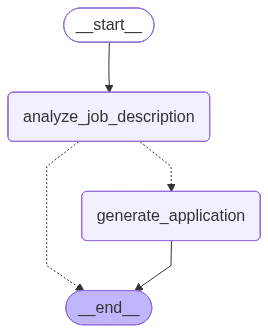

In [62]:
from typing_extensions import TypedDict
from typing import Annotated, Literal
from operator import add
from pydantic import BaseModel, Field


new_prompt_template = (
    "Given a job description, decide whether it suits a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n"
    "Answer only YES or NO."
)

class ModelResponse(BaseModel):
    suitability: Literal['YES', 'NO'] = Field(..., description='Whether the job description suits a junior Java developer')

model = ChatOpenAI(model='gpt-5-nano')
model_with_format = model.with_structured_output(ModelResponse)

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    suitability_result: ModelResponse # Include the structured response in the state with proper typing
    application: str
    actions: Annotated[list[str], add]

def analyze_job_description(state: JobApplicationState):
    result: ModelResponse = model_with_format.invoke(
        new_prompt_template.format(job_description=state["job_description"])
    )
    return {
        "suitability_result": result,
        "is_suitable": result.suitability == "YES",
    }

def is_suitable_condition(state: JobApplicationState) -> Literal['generate_application', '__end__']:
    if state.get('is_suitable'):
        return 'generate_application'
    return END

def generate_application(state: JobApplicationState):
    ai_message = model.invoke(f"Generate a short job application for the following job description: {state['job_description']}")
    application = ai_message.content
    return {"application": application}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges(
    'analyze_job_description',
    is_suitable_condition
)
builder.add_edge('generate_application', END)
graph = builder.compile()

display_graph(graph)

In [ ]:
job_description: str = "We are looking for a Data Scientist with experience in Python and LangChain"
result = graph.invoke({'job_description': job_description})

In [58]:
result

{'job_description': 'We are looking for a Data Scientist with experience in Python and LangChain',
 'is_suitable': False,
 'suitability_result': ModelResponse(suitability='NO'),
 'actions': []}

In [63]:
job_description: str = "We are looking for a entry-level backend developer with experience in Java"
result2 = graph.invoke({'job_description': job_description})

/Users/npop/miniforge3/envs/agent_env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ModelResponse(suitability='YES'), input_type=ModelResponse])
  return self.__pydantic_serializer__.to_python(


In [64]:
result2

{'job_description': 'We are looking for a entry-level backend developer with experience in Java',
 'is_suitable': True,
 'suitability_result': ModelResponse(suitability='YES'),
 'application': 'Dear Hiring Team,\n\nI am writing to apply for the entry-level backend developer position that requires Java experience. I recently earned a B.S. in Computer Science and have practical backend development experience with Java, Spring Boot, and RESTful APIs through internships and projects. I’ve built scalable services, connected to PostgreSQL, implemented secure endpoints, and created unit tests with JUnit. I am proficient with Maven, Git, and basic CI/CD workflows, and I enjoy collaborating in Agile teams to deliver reliable software.\n\nKey qualifications:\n- Java, Spring Boot, RESTful APIs\n- SQL databases (PostgreSQL/MySQL), data modeling\n- Hibernate/JPA, caching basics\n- Build tools: Maven/Gradle; Git; CI/CD basics\n- Testing: JUnit, Mockito\n\nI am eager to contribute to your backend tea